# S&P 500 Equity+Option - IV-RV Spread: Causal DML Sensitivity Analysis

Does the negative association between the implied-realized volatility spread
and future equity returns remain after adjustment for observed confounders?
This notebook applies DML to `ivrv_spread` across a retrospective panel drawn
from the current-constituent roster, with option-derived features at daily
frequency.

**Treatment rationale**: The IV-RV spread captures option mispricing - when
implied volatility exceeds realized, options are "expensive." Realized
volatility (20d), equity momentum (21d), and risk-reversal skew (25-delta,
30d) confound this relationship because all three co-move with investor fear
and positioning.

The estimand, the analysis population, the cross-fitting geometry and the
refutation design are resolved by the shared causal request rather than
assembled here. The request verifies that the treatment and every confounder
exist, excludes outcomes whose horizon reaches the holdout, keeps complete
decision-time panels, cross-fits with an embargo, and records the placebo
block design in the causal identity. This notebook inspects what it resolved,
runs it, and reports the result.

**Learning Objectives**:
- Keep the holdout outside an exploratory causal analysis
- Read the estimand and its temporal controls off the resolved specification
- Compare the adjusted estimate with naive OLS and a block-permutation null

**Book Reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence)

**Prerequisites**: `03_financial_features.py`, `04_model_based_features.py`

## Identifying Assumptions

DML identifies a causal effect only if three assumptions hold:
1. **Conditional ignorability**: No unobserved confounders - all backdoor paths
   between treatment and outcome are blocked by the observed confounders.
2. **Overlap (positivity)**: Every unit has a nonzero probability of receiving
   any treatment level, conditional on confounders.
3. **SUTVA**: One unit's treatment doesn't affect another's outcome.

These are untestable. The refutation test below provides indirect evidence
but cannot prove the assumptions hold.

In [1]:
"""Estimate and register the configured equity-option causal DML specification."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from case_studies.research import ExecutionTier, causal_supersedes, open_study
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
CV_FOLDS = 0
MAX_SAMPLES = 0
N_PLACEBO = 0
FORCE_RETRAIN = False
# The tier is declared, not inferred from whether a reduction happens to be set: a reduced run
# that still opened the case study's own artifacts in place would be writing down the
# production path. WORKSPACE is the other half - a preview has nowhere else to write.
EXECUTION_TIER = "canonical"
WORKSPACE: str | None = None
# Empty because this registry holds no *current* causal identity for the label, not because
# nothing came before. `b47bd0ec208a` is the capped fit of 2026-08-26 - 37,240 rows, 9.9% of
# the panel this request resolves - and it was written by the previous notebook under a spec
# with no `identity_version`, so `current_causal_identities` does not return it and no reader
# resolves it. There is nothing to retire: it is stranded rather than superseded, and naming it
# would fail the write for declaring a predecessor that is not current.
#
# Declare the hash here once this run leaves a current identity and a later change moves it -
# a refit under a changed block size, fold count or population - or registration refuses the
# write after the fit and all 100 placebo refits have been paid for. `causal_supersedes` then
# withholds the declaration against a reader's clone, which holds no causal rows at all, so one
# committed value is right for both. That resolution has to happen against the registry rather
# than at run time: `run-production-notebook.sh` executes with no parameter overrides, so a
# value supplied only as an override could never be stamped.
SUPERSEDES_CAUSAL: str = ""

## Resolve the estimand and analysis population

Nonzero fold, sample, symbol, or placebo limits declare a preview. They are recorded in
identity and excluded from canonical evidence, so the published estimate cannot silently be a
reduced one.

In [3]:
setup = yaml.safe_load((get_case_study_dir(CASE_STUDY_ID) / "config" / "setup.yaml").read_text())
label = PRIMARY_LABEL or setup["labels"]["primary"]

if FORCE_RETRAIN:
    raise ValueError("an identical complete causal request is reused; change the request to refit")

REDUCTION_PARAMETERS = {
    "max_symbols": MAX_SYMBOLS or None,
    "n_folds": CV_FOLDS or None,
    "max_samples": MAX_SAMPLES or None,
    "n_placebo": N_PLACEBO or None,
}
reductions = {key: value for key, value in REDUCTION_PARAMETERS.items() if value is not None}
tier = ExecutionTier(EXECUTION_TIER)
if tier is ExecutionTier.PREVIEW and not reductions:
    raise ValueError("preview execution must declare at least one reduction")
if tier is ExecutionTier.CANONICAL and reductions:
    raise ValueError(f"canonical execution cannot carry reductions: {sorted(reductions)}")

study = open_study(CASE_STUDY_ID, execution_tier=tier, workspace=WORKSPACE or None)
request = study.causal(
    method="dml",
    label=label,
    config_name="dml",
    execution_tier=tier,
    preview_reductions=reductions,
    overrides={},
    supersedes=causal_supersedes(
        study, SUPERSEDES_CAUSAL, label, labels=[label], execution_tier=tier.value
    ),
)
resolved = request.resolve()
computation = resolved.spec["computation"]
estimand = computation["estimand"]
# Seeded from the identity rather than from a notebook parameter. The seed the estimate depends
# on is `dml.yaml`'s, and it is in the resolved specification and therefore in the hash; a
# parameter beside it would be a dial a reader can turn that changes nothing, and worse, turning
# it would leave the identity untouched and reload the cached result under a seed it was not fit
# with. The nuisance estimator and the placebo permutation carry this seed explicitly; the global
# call covers whatever else in the stack reads a process-wide one.
set_global_seeds(int(resolved.spec["seed"]))

print(f"Case study: {CASE_STUDY_ID}")
print(f"Treatment: {estimand['treatment']}")
print(f"Outcome: {estimand['outcome']} (horizon {estimand['outcome_horizon']})")
print(f"Confounders: {', '.join(estimand['confounders'])}")
print(f"Execution tier: {tier.value} | seed {resolved.spec['seed']}")
print(f"Last admissible outcome endpoint: {estimand['holdout_endpoint_cutoff']}")

Case study: sp500_equity_option_analytics
Treatment: ivrv_spread
Outcome: fwd_ret_5d (horizon 5 days 00:00:00)
Confounders: rv_20, mom_21d, skew_rr_30_25d
Execution tier: canonical | seed 42
Last admissible outcome endpoint: 2020-12-17T00:00:00


> **Scope**: This is a development-period sensitivity analysis, not a holdout
> evaluation. The request excludes every observation whose outcome window could
> reach past `holdout_endpoint_cutoff`, and it keeps complete cross-sections, so
> neither folds nor embargoes cut through a decision time.

> **Population scope**: The source universe is a current-constituent roster,
> not point-in-time S&P 500 membership. Firms removed from the index before
> the roster date are absent. The estimate therefore describes this
> retrospective roster during the development period; it does not generalize
> to the historical index-membership process or a prospective S&P 500
> population.

## 1. Inspect the temporal controls

Three quantities decide how this estimate is measured, and they answer different questions.

The **embargo** separates a fold's training window from its test window, so a label measured
in training cannot still be running when testing starts. `labels.buffer` sets it, and that
buffer is declared deliberately longer than the outcome it protects, so it is not a statement
about the outcome. The **outcome horizon** is how long one outcome stays open, and it is what
the Driscoll-Kraay bandwidth is sized by: a bandwidth shorter than the overlap between
successive outcomes understates the standard error. The **permutation block size** is the
scale of the dependence the placebo has to preserve: shuffling in blocks shorter than that
scale pulls dependent observations apart and the placebo degrades towards an independent draw
- the permutation that is too easy to pass and therefore proves nothing.

**Two scales qualify for the block size, and it has to cover both.** One is the outcome
horizon. The other is the treatment's own persistence: `ivrv_spread` subtracts a 20-session
rolling realized volatility from implied, so consecutive values share most of their input and
stay dependent over that rolling window whatever the label does. It is the longer of the two
here, and `causal.treatment_window` in `config/setup.yaml` declares it beside the derivation
that produced it, because no rule can read a construction window off a column name.

The table prints the block the run used beside both scales it has to span, read from the
resolved specification rather than from `setup.yaml`, so it shows what the run used rather
than what the file asks for.

In [4]:
pl.DataFrame(
    {
        "label": [resolved.spec["label"]],
        "cross_fitting_folds": [computation["cv"]["n_folds"]],
        "embargo_periods": [computation["cv"]["embargo_periods"]],
        "fold_unit": [computation["cv"]["fold_unit"]],
        "label_buffer_steps": [computation["refutation"]["label_buffer_steps"]],
        "label_horizon_steps": [computation["refutation"]["label_horizon_steps"]],
        "treatment_window_steps": [computation["refutation"]["treatment_window_steps"]],
        "placebo_method": [computation["refutation"]["method"]],
        "placebo_block_size": [computation["refutation"]["block_size"]],
        "block_size_basis": [computation["refutation"]["block_size_basis"]],
        "placebo_draws": [computation["refutation"]["n_placebo"]],
        "analysis_rows": [computation["analysis_population"]["n_rows"]],
        "analysis_timestamps": [computation["analysis_population"]["n_timestamps"]],
        "analysis_key_digest": [computation["analysis_population"]["key_digest"]],
    }
)

label,cross_fitting_folds,embargo_periods,fold_unit,label_buffer_steps,label_horizon_steps,treatment_window_steps,placebo_method,placebo_block_size,block_size_basis,placebo_draws,analysis_rows,analysis_timestamps,analysis_key_digest
str,i64,i64,str,i64,i64,i64,str,i64,str,i64,i64,i64,str
"""fwd_ret_5d""",5,10,"""complete_timestamp_panel""",10,5,20,"""within_symbol_contiguous_block…",20,"""treatment_window""",100,376871,976,"""0be1c07ea5541f12"""


## 2. Estimate or reload the causal result

Registration happens only after the fit returns a finite effect and HAC standard error. A
missing treatment, confounder, or valid analysis population fails before any causal row is
written.

In [5]:
result = resolved.run()
if not result.complete:
    raise RuntimeError(f"the causal result for {label} is incomplete")
# Compare the identity-bearing computation, not the whole specification. `provenance` records
# the git commit of the run that registered the result, so a full-spec comparison fails on any
# re-run made after any commit - it would assert that nothing had been committed since, which is
# not a property of the causal estimate.
if result.spec["computation"] != computation:
    raise RuntimeError(f"the registered causal computation for {label} differs")
reloaded = request.resolve().run()
if reloaded.hash != result.hash:
    raise RuntimeError(f"reloading the causal request for {label} changed its identity")

print(f"Registered causal identity: {result.hash}")

Registered causal identity: b8e949f2cbc5


## 3. Statistical Assessment

Confounding bias is defined as:

$$\text{Bias \%} = \frac{\hat{\theta}_{\text{naive}} - \hat{\theta}_{\text{DML}}}{|\hat{\theta}_{\text{DML}}|} \times 100$$

Positive values mean the naive coefficient is more positive than the adjusted
coefficient; interpret the sign alongside both coefficients.

The two diagnostics answer different questions. Driscoll-Kraay inference asks whether the
adjusted coefficient is distinguishable from zero after allowing for panel dependence. The
block permutation asks whether its magnitude is unusual after disrupting the treatment-outcome
timing while preserving each entity's short-run treatment dependence. Neither test validates
the unobserved-confounding assumption.


Two numbers below are populations and they are not the same one. The **analysis population** is
what the request resolved: every row admissible under the estimand and the holdout cutoff.
**Cross-fitted observations** is the subset carrying an out-of-fold residual, which is what the
coefficient is computed on - a row outside every fold's validation window contributes nothing
to it by construction.

The refutation verdict is derived from the p-value **and** the number of placebo refits that
succeeded, because a p-value alone cannot say whether the draws could have rejected at all.

**Read the refutation against the warning the run prints above it**, which reports the share of
treatment rows the permutation could not move. A row is frozen when its symbol's segment is too
short to hold two blocks, and a 20-session block needs 40 clean sessions to have anywhere to go,
so a daily option panel freezes a large share: every gap in a symbol's quotes starts a new
segment. A frozen row keeps its observed treatment in every placebo, which pulls the placebo
distribution towards the observed estimate and biases the p-value **towards 1**. The bias works
against rejecting, so a refutation that passes with a large frozen share has passed a harder
test than the number suggests - which is the opposite of the reading a frozen share usually
warrants, and the reason it is worth checking rather than assuming.

In [6]:
metrics = result.metrics
dml_effect = metrics["dml_effect"]
se_hac = metrics["dml_se_hac"]
refutation_p = metrics["refutation_p"]

print(f"Analysis population: {computation['analysis_population']['n_rows']:,} rows")
print(f"Cross-fitted observations: {metrics['n_obs']:,}")
print(f"Naive OLS effect:  {metrics['naive_effect']:+.6f}")
print(f"Adjusted (DML):    {dml_effect:+.6f}  (HAC SE {se_hac:.6f})")
print(f"95% interval:      [{dml_effect - 1.96 * se_hac:+.6f}, {dml_effect + 1.96 * se_hac:+.6f}]")
print(f"Confounding bias:  {metrics['confounding_bias_pct']:+.2f}%")
print(f"p-value (HAC):     {metrics['p_value_hac']:.4f}")
print(f"  Significant at 5%: {'Yes' if metrics['p_value_hac'] < 0.05 else 'No'}")
print(
    f"Refutation:        {metrics['refutation_class']} "
    f"(p={refutation_p:.4f}, {metrics['refutation_n_successful']} successful draws)"
)

Analysis population: 376,871 rows
Cross-fitted observations: 313,237
Naive OLS effect:  -0.018040
Adjusted (DML):    +0.015345  (HAC SE 0.016828)
95% interval:      [-0.017638, +0.048328]
Confounding bias:  -217.56%
p-value (HAC):     0.3621
  Significant at 5%: No
Refutation:        Passes (p=0.0099, 100 successful draws)


**Interpretation**: The DML coefficient is an adjusted conditional estimate,
not proof that changing the IV-RV spread would change returns. Its causal
interpretation still depends on the identifying assumptions above. Compare
the naive and adjusted coefficients to see how observed confounders change the
estimated association.

Compare this result with the S&P 500 Options case study to see why confounding
must be assessed for each treatment-outcome pair rather than inferred from the
market alone.

> **When should you be suspicious of large DML corrections?** A naive-to-DML
> amplification exceeding 5x warrants scrutiny. Possible causes:
> (1) nuisance models overfitting and stripping outcome-relevant variation,
> (2) weak instrument-like behavior where the treatment residual has low variance,
> (3) genuine massive confounding that naive OLS entirely misses.
> The refutation test helps distinguish (3) from (1-2): if placebos also show
> inflated effects, the DML correction may be unreliable.

### Permutation Distribution

The adjusted estimate against the distribution of placebo effects from
within-entity block permutations of the treatment.

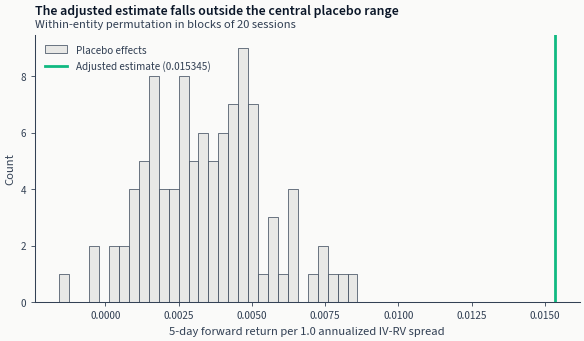

In [7]:
placebo_arr = np.asarray(metrics["placebo_effects"], dtype=float)
if placebo_arr.size == 0:
    # The registry stores the draws beside the p-value, so an empty array here is a row written
    # before that column existed rather than a refutation that did not run. Say which, instead
    # of showing an empty axis.
    print("This causal row predates the stored placebo draws; the p-value above is the test.")
else:
    fig, ax = plt.subplots(figsize=FIGSIZE["single"])
    ax.hist(
        placebo_arr,
        bins=30,
        color=COLORS["silver_muted"],
        edgecolor=COLORS["neutral"],
        linewidth=0.5,
        label="Placebo effects",
    )
    ax.axvline(
        dml_effect,
        color=COLORS["negative"] if dml_effect < 0 else COLORS["positive"],
        linewidth=2,
        label=f"Adjusted estimate ({dml_effect:.6f})",
    )
    relation = "outside" if refutation_p < 0.05 else "inside"
    add_message_title(
        ax,
        f"The adjusted estimate falls {relation} the central placebo range",
        subtitle=(
            f"Within-entity permutation in blocks of "
            f"{computation['refutation']['block_size']} sessions"
        ),
    )
    ax.set_xlabel("5-day forward return per 1.0 annualized IV-RV spread")
    ax.set_ylabel("Count")
    ax.legend()
    plt.show()

## Key Takeaways

1. **The holdout is never read**: the request drops every observation whose outcome window
   could reach past the holdout endpoint cutoff, so exploratory causal diagnostics cannot
   influence or consume the final evaluation window.

2. **Read the coefficient against its panel-aware standard error, not against zero**:
   the DML estimate is a five-day return per one annualized unit of IV-RV spread, and the
   Driscoll-Kraay standard error beside it is the one that allows for both serial and
   cross-sectional dependence.

3. **Compare naive OLS and DML on the same rows**: `confounding_bias_pct` is the gap
   between them as a share of the adjusted estimate. Both are computed on the cross-fitted
   observations - the smaller of the two counts reported above, not the analysis population
   - so the difference between them is adjustment rather than sample.

4. **The estimand is part of the identity**: treatment, confounders, temporal geometry and
   refutation design all enter the hashed specification, so a run at a different block size,
   placebo count, seed, fold count or population registers as its own result rather than
   overwriting the one before it.

5. **A refutation is evidence about timing, not about confounding**: a causal reading still
   requires conditional ignorability, overlap, and SUTVA, none of which any test here can
   establish.